# Chất lượng dữ liệu POI — EDA

Có nhận xét rằng dữ liệu POI *"tương đối tệ"*. Notebook này đo xem **tệ tới mức nào**, và
quan trọng hơn: **tệ theo kiểu nào**.

Phân biệt đó quyết định mọi thứ:

| Kiểu khuyết | Hậu quả |
|---|---|
| **Thiếu NGẪU NHIÊN** — mọi nơi đều thiếu như nhau | chỉ là nhiễu; giảm độ nhạy, không tạo kết luận sai |
| **Thiếu CÓ HỆ THỐNG** — nơi này thiếu nhiều hơn nơi kia | **tạo ra cấu trúc giả**; mọi bản đồ POI sẽ vẽ lại *công sức lập bản đồ* rồi gọi nó là *đặc điểm đô thị* |

Bảy phần bên dưới, phần 7 là phần trả lời *"vậy có dùng được không"*.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from scipy.spatial import cKDTree
from scipy.stats import spearmanr

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 9,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
RNG = 20260807

poi = pq.read_table(ROOT / "data/qa/critique/poi_extended.parquet").to_pandas()
grid = pq.read_table(ROOT / "data/processed/grid_h3_r8.parquet").to_pandas()
com = pq.read_table(ROOT / "data/processed/commune.parquet").to_pandas()
grid["loai"] = np.where(grid.commune_name.str.startswith("Phường"), "Phường", "Xã")
poi = poi[poi.h3_r8.isin(set(grid.h3_r8))].copy()

print(
    f"{len(poi):,} POI · {poi.poi_class.nunique()} lớp · {len(grid):,} ô · dân {grid.population.sum():,.0f}"
)

20,691 POI · 18 lớp · 4,400 ô · dân 8,831,126


## 1 — Độ lớn của khoảng trống

Trước khi bàn thiên lệch, phải biết khối lượng thiếu là bao nhiêu.

POI trên 1.000 dân : 2.34
POI trên km²       : 5.82

ô KHÔNG có POI nào trong ô     : 3,814/4,400 = 86.7%
ô KHÔNG có POI nào trong 1 km  : 3,186/4,400 = 72.4%
→ DÂN sống ở những ô đó        : 3,124,090 = 35.4% dân Hà Nội


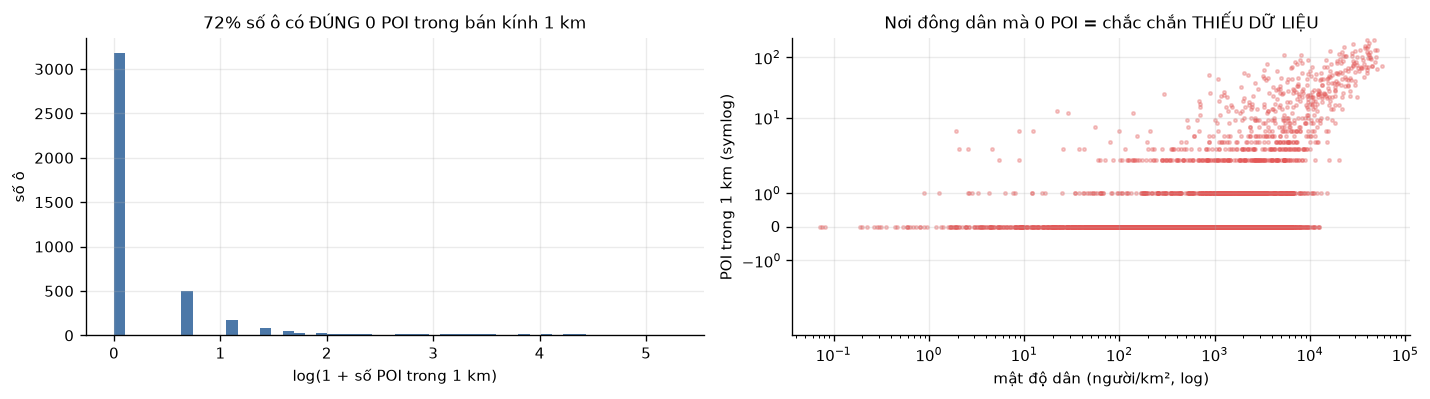


Ô có mật độ > 5.000 người/km² MÀ 0 POI trong 1 km: 105 ô, 585,636 người
→ Đây không phải 'vùng vắng', đây là LỖ HỔNG DỮ LIỆU.


In [2]:
dan = grid.population.sum()
dt = grid.area_km2.sum()
print(f"POI trên 1.000 dân : {len(poi) / dan * 1000:.2f}")
print(f"POI trên km²       : {len(poi) / dt:.2f}")
print()
n0_o = (grid.n_poi_total == 0).sum()
n0_1km = (grid.n_poi_1km == 0).sum()
dan0 = grid.loc[grid.n_poi_1km == 0, "population"].sum()
print(f"ô KHÔNG có POI nào trong ô     : {n0_o:,}/{len(grid):,} = {n0_o / len(grid):.1%}")
print(f"ô KHÔNG có POI nào trong 1 km  : {n0_1km:,}/{len(grid):,} = {n0_1km / len(grid):.1%}")
print(f"→ DÂN sống ở những ô đó        : {dan0:,.0f} = {dan0 / dan:.1%} dân Hà Nội")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(np.log1p(grid.n_poi_1km), bins=50, color="#4C78A8")
ax[0].set_xlabel("log(1 + số POI trong 1 km)")
ax[0].set_ylabel("số ô")
ax[0].set_title(f"{n0_1km / len(grid):.0%} số ô có ĐÚNG 0 POI trong bán kính 1 km", fontsize=10)
sc = ax[1].scatter(grid.pop_density_ppkm2, grid.n_poi_1km, s=4, alpha=0.3, c="#E45756")
ax[1].set_xscale("log")
ax[1].set_yscale("symlog")
ax[1].set_xlabel("mật độ dân (người/km², log)")
ax[1].set_ylabel("POI trong 1 km (symlog)")
ax[1].set_title("Nơi đông dân mà 0 POI = chắc chắn THIẾU DỮ LIỆU", fontsize=10)
plt.tight_layout()
plt.show()

dong_ma_trong = grid[(grid.n_poi_1km == 0) & (grid.pop_density_ppkm2 > 5000)]
print(
    f"\nÔ có mật độ > 5.000 người/km² MÀ 0 POI trong 1 km: {len(dong_ma_trong)} ô, "
    f"{dong_ma_trong.population.sum():,.0f} người"
)
print("→ Đây không phải 'vùng vắng', đây là LỖ HỔNG DỮ LIỆU.")

## 2 — Đối chứng "sự thật đã biết"

Phép kiểm mạnh nhất cho tính đầy đủ không cần nguồn ngoài: có những thứ **chắc chắn tồn
tại**. Mọi xã/phường ở Việt Nam đều có **trường học**. Mọi nơi có người ở đều có **chỗ ăn
uống**. Nếu OSM báo 0, đó là **khuyết dữ liệu đã được chứng minh**, không phải suy đoán.

,thứ chắc chắn tồn tại,xã/phường báo 0,trên tổng,% khuyết,dân ở vùng khuyết
lớp,,,,,
GIAO_DUC,trường học,0,126,0.0%,0
AN_UONG,chỗ ăn uống,35,126,27.8%,"2,055,978"
BAN_LE_KHAC,cửa hàng bán lẻ,32,126,25.4%,"1,715,246"
Y_TE,cơ sở y tế,34,126,27.0%,"1,850,147"
MARKET,chợ,60,126,47.6%,"3,503,242"
FUEL,cây xăng,27,126,21.4%,"1,571,204"


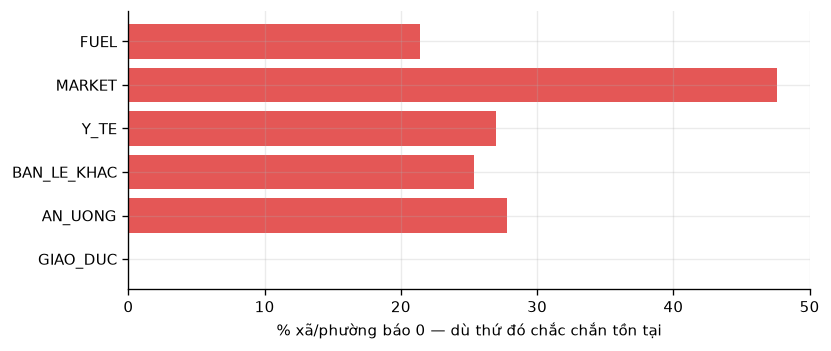

In [3]:
poi["commune_code"] = poi.h3_r8.map(dict(zip(grid.h3_r8, grid.commune_code)))
ct = poi.pivot_table(index="commune_code", columns="poi_class", aggfunc="size", fill_value=0)
ct = ct.reindex(com.commune_code).fillna(0)
ct["population"] = com.set_index("commune_code").population.reindex(ct.index).to_numpy()
co_dan = ct[ct.population > 0]

kiem = []
for lop, chac_chan_co in [
    ("GIAO_DUC", "trường học"),
    ("AN_UONG", "chỗ ăn uống"),
    ("BAN_LE_KHAC", "cửa hàng bán lẻ"),
    ("Y_TE", "cơ sở y tế"),
    ("MARKET", "chợ"),
    ("FUEL", "cây xăng"),
]:
    if lop not in co_dan:
        continue
    n0 = int((co_dan[lop] == 0).sum())
    kiem.append(
        {
            "lớp": lop,
            "thứ chắc chắn tồn tại": chac_chan_co,
            "xã/phường báo 0": n0,
            "trên tổng": len(co_dan),
            "% khuyết": n0 / len(co_dan),
            "dân ở vùng khuyết": int(co_dan.loc[co_dan[lop] == 0, "population"].sum()),
        }
    )
K = pd.DataFrame(kiem).set_index("lớp")
display(K.style.format({"% khuyết": "{:.1%}", "dân ở vùng khuyết": "{:,.0f}"}))

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(K.index, K["% khuyết"] * 100, color="#E45756")
ax.set_xlabel("% xã/phường báo 0 — dù thứ đó chắc chắn tồn tại")
plt.tight_layout()
plt.show()

## 3 — Thiếu ngẫu nhiên hay thiếu có hệ thống?

Đây là câu hỏi trung tâm. Cách kiểm: nếu thiếu **ngẫu nhiên**, thì tỉ lệ *POI trên mỗi đơn
vị hoạt động con người* phải như nhau ở mọi nơi. Ta không đo được "hoạt động con người",
nhưng có ba biến thay thế **độc lập với OSM POI**: dân số, diện tích đã xây (ảnh vệ tinh
ESA), và chiều dài đường.

Nếu POI trên đầu người ở nội thành cao gấp nhiều lần ngoại thành, thì hoặc là (a) người
nội thành thật sự có nhiều cửa hàng hơn *trên đầu người*, hoặc (b) nội thành **được vẽ kỹ
hơn**. Không tách được hai cái bằng chính dữ liệu POI — nhưng **độ lớn** của chênh lệch nói
lên rất nhiều.

In [4]:
gg = grid.groupby("loai").agg(
    dan=("population", "sum"),
    dt=("area_km2", "sum"),
    poi=("n_poi_total", "sum"),
    xay=("built_frac", "mean"),
    duong=("road_len_m", "sum"),
)
gg["POI/1000 dân"] = gg.poi / gg.dan * 1000
gg["POI/km²"] = gg.poi / gg.dt
gg["POI/km² đã xây"] = gg.poi / (gg.dt * gg.xay)
gg["POI/100 km đường"] = gg.poi / (gg.duong / 1000) * 100
display(gg[["POI/1000 dân", "POI/km²", "POI/km² đã xây", "POI/100 km đường"]].round(2))

ty = (gg.loc["Phường"] / gg.loc["Xã"])[
    ["POI/1000 dân", "POI/km²", "POI/km² đã xây", "POI/100 km đường"]
]
print("\nPhường gấp Xã bao nhiêu lần, theo từng mẫu số:")
for k, v in ty.items():
    print(f"  {k:22} {v:6.2f}×")
print("\nNếu mọi mẫu số đều cho ~cùng một tỉ lệ, chênh lệch là THẬT (nội thành đông đúc hơn).")
print("Nếu tỉ lệ vẫn cao kể cả khi chuẩn hoá theo DIỆN TÍCH ĐÃ XÂY, đó là dấu hiệu CÔNG SỨC VẼ.")

,POI/1000 dân,POI/km²,POI/km² đã xây,POI/100 km đường
loai,,,,
Phường,0.81,8.26,18.93,48.16
Xã,0.13,0.20,1.34,2.65



Phường gấp Xã bao nhiêu lần, theo từng mẫu số:
  POI/1000 dân             6.11×
  POI/km²                 41.76×
  POI/km² đã xây          14.12×
  POI/100 km đường        18.18×

Nếu mọi mẫu số đều cho ~cùng một tỉ lệ, chênh lệch là THẬT (nội thành đông đúc hơn).
Nếu tỉ lệ vẫn cao kể cả khi chuẩn hoá theo DIỆN TÍCH ĐÃ XÂY, đó là dấu hiệu CÔNG SỨC VẼ.


## 4 — Bất bình đẳng: POI tập trung hơn dân số bao nhiêu?

Đường Lorenz và hệ số Gini. Nếu POI phân bố **tập trung hơn hẳn** dân số và hơn cả diện
tích đã xây, thì phần chênh đó rất khó giải thích bằng gì khác ngoài công sức lập bản đồ.

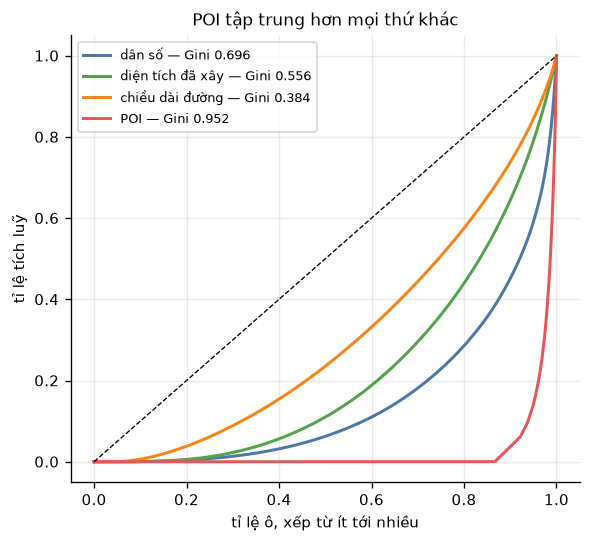

In [5]:
def lorenz(v):
    v = np.sort(np.asarray(v, float))
    if v.sum() <= 0:
        return np.linspace(0, 1, len(v) + 1), np.linspace(0, 1, len(v) + 1), 0.0
    c = np.concatenate([[0], np.cumsum(v) / v.sum()])
    x = np.linspace(0, 1, len(c))
    return x, c, float(1 - 2 * np.trapezoid(c, x))


fig, ax = plt.subplots(figsize=(5, 4.6))
for ten, v, col in [
    ("dân số", grid.population, "#4C78A8"),
    ("diện tích đã xây", grid.built_frac * grid.area_km2, "#54A24B"),
    ("chiều dài đường", grid.road_len_m, "#F58518"),
    ("POI", grid.n_poi_total, "#E45756"),
]:
    x, c, gini = lorenz(v)
    ax.plot(x, c, label=f"{ten} — Gini {gini:.3f}", color=col, lw=1.8)
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("tỉ lệ ô, xếp từ ít tới nhiều")
ax.set_ylabel("tỉ lệ tích luỹ")
ax.legend(fontsize=8, loc="upper left")
ax.set_title("POI tập trung hơn mọi thứ khác", fontsize=10)
plt.tight_layout()
plt.show()

## 5 — Niên đại và tính đầy đủ của thuộc tính

Mã OSM được cấp **tăng dần theo thời gian**, nên phân bố mã là proxy cho tuổi dữ liệu. Còn
thuộc tính thì đo trực tiếp.

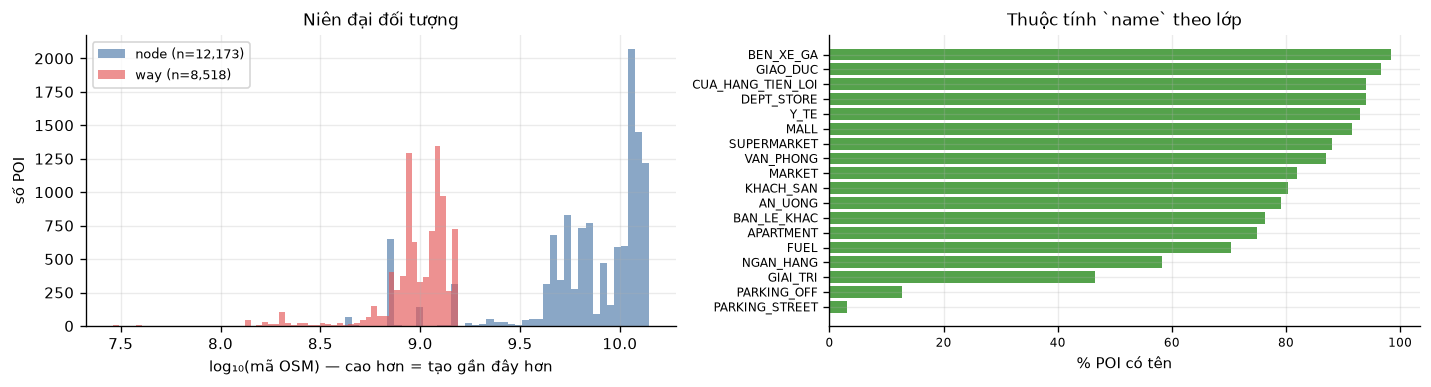

POI có tên: 77.1%
POI là NODE (một điểm): 58.8% · WAY (lấy tâm đa giác): 41.2%


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.3))
for t, col in [("node", "#4C78A8"), ("way", "#E45756")]:
    s = poi[poi.osm_type == t].osm_id
    if len(s):
        ax[0].hist(np.log10(s), bins=60, alpha=0.65, label=f"{t} (n={len(s):,})", color=col)
ax[0].set_xlabel("log₁₀(mã OSM) — cao hơn = tạo gần đây hơn")
ax[0].set_ylabel("số POI")
ax[0].legend(fontsize=8)
ax[0].set_title("Niên đại đối tượng", fontsize=10)

thuoc_tinh = poi.groupby("poi_class").name.agg(["size", lambda s: s.notna().mean()])
thuoc_tinh.columns = ["n", "có tên"]
thuoc_tinh = thuoc_tinh.sort_values("có tên")
ax[1].barh(thuoc_tinh.index, thuoc_tinh["có tên"] * 100, color="#54A24B")
ax[1].set_xlabel("% POI có tên")
ax[1].tick_params(labelsize=7)
ax[1].set_title("Thuộc tính `name` theo lớp", fontsize=10)
plt.tight_layout()
plt.show()

print(f"POI có tên: {poi.name.notna().mean():.1%}")
print(
    f"POI là NODE (một điểm): {(poi.osm_type == 'node').mean():.1%} · "
    f"WAY (lấy tâm đa giác): {(poi.osm_type == 'way').mean():.1%}"
)

**Vì sao `way` đáng chú ý.** POI dạng `way` là một đa giác, và toạ độ dùng ở đây là **tâm
hình học** của nó. Với một trung tâm thương mại 200 m × 200 m, tâm có thể lệch tới ~140 m
so với cửa vào thật. Ở bán kính 300 m thì sai số đó là đáng kể — đây là một lý do nữa để
bán kính nhỏ dự báo kém hơn bán kính 1 km (l5 §9.2).

In [7]:
# --- trùng lặp: cùng lớp, cách nhau dưới 25 m ---
M_LAT, M_LON = 110_574.0, 103_940.0
XY = np.c_[poi.lng.to_numpy() * M_LON, poi.lat.to_numpy() * M_LAT]
tr = cKDTree(XY)
cap = tr.query_pairs(25, output_type="ndarray")
cls = poi.poi_class.to_numpy()
cung_lop = cap[cls[cap[:, 0]] == cls[cap[:, 1]]]
print(f"cặp POI cách nhau < 25 m           : {len(cap):,}")
print(
    f"trong đó CÙNG LỚP (nghi trùng lặp) : {len(cung_lop):,} "
    f"= {len(cung_lop) / len(poi):.1%} so với tổng POI"
)
if len(cung_lop):
    print("phân bố theo lớp:", pd.Series(cls[cung_lop[:, 0]]).value_counts().head(5).to_dict())

cặp POI cách nhau < 25 m           : 22,543
trong đó CÙNG LỚP (nghi trùng lặp) : 10,057 = 48.6% so với tổng POI
phân bố theo lớp: {'BAN_LE_KHAC': 5174, 'AN_UONG': 3078, 'NGAN_HANG': 651, 'KHACH_SAN': 531, 'VAN_PHONG': 255}


## 6 — Lớp nào được vẽ kỹ, lớp nào bị bỏ quên?

Nếu công sức lập bản đồ **khác nhau giữa các lớp**, thì ngay cả vectơ **tỉ trọng** — thứ ta
dùng để khử thiên lệch mật độ ở l5 §3 — cũng vẫn méo. Đây là hạn chế mà tỉ trọng **không**
chữa được, và cần đo riêng.

loai,Phường,Xã,P/1000 dân,X/1000 dân,tỉ lệ P:X
poi_class,,,,,
FUEL,155,155,0.038,0.033,1.145
GIAO_DUC,1234,1141,0.300,0.242,1.238
GIAI_TRI,527,226,0.128,0.048,2.670
MARKET,136,52,0.033,0.011,2.994
Y_TE,261,95,0.063,0.020,3.146
BEN_XE_GA,49,17,0.012,0.004,3.300
PARKING_OFF,390,105,0.095,0.022,4.253
CUA_HANG_TIEN_LOI,1031,189,0.250,0.040,6.246
VAN_PHONG,1420,260,0.345,0.055,6.253


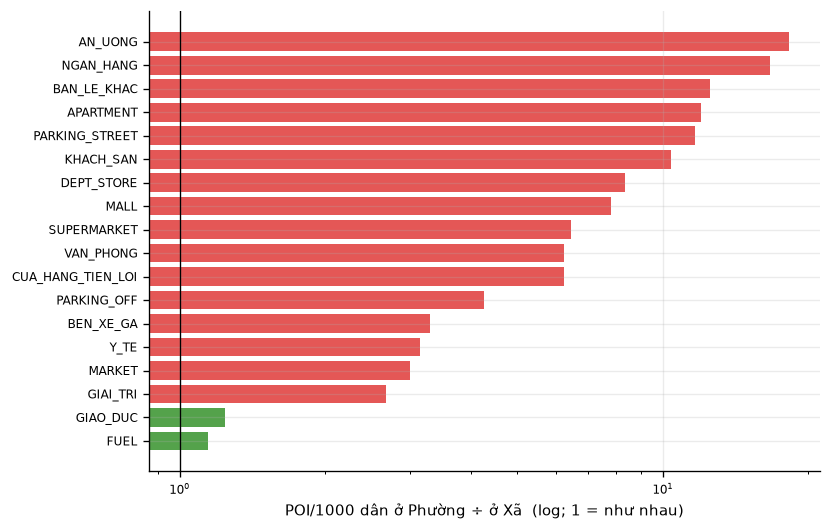

Nếu các lớp trải rộng nhiều bậc, công sức vẽ KHÁC NHAU giữa các lớp — và tỉ trọng
thành phần cũng không khử được điều đó.


In [8]:
tt = poi.assign(loai=poi.h3_r8.map(dict(zip(grid.h3_r8, grid.loai))))
bang = tt.pivot_table(index="poi_class", columns="loai", aggfunc="size", fill_value=0)
dan_p = grid[grid.loai == "Phường"].population.sum()
dan_x = grid[grid.loai == "Xã"].population.sum()
bang["P/1000 dân"] = bang.get("Phường", 0) / dan_p * 1000
bang["X/1000 dân"] = bang.get("Xã", 0) / dan_x * 1000
bang["tỉ lệ P:X"] = bang["P/1000 dân"] / bang["X/1000 dân"].replace(0, np.nan)
bang = bang.sort_values("tỉ lệ P:X")
display(bang.round(3))

fig, ax = plt.subplots(figsize=(7, 4.5))
v = bang["tỉ lệ P:X"].dropna()
ax.barh(v.index, v.to_numpy(), color=["#54A24B" if x < 2 else "#E45756" for x in v])
ax.axvline(1, color="k", lw=0.8)
ax.set_xscale("log")
ax.set_xlabel("POI/1000 dân ở Phường ÷ ở Xã  (log; 1 = như nhau)")
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()
print("Nếu các lớp trải rộng nhiều bậc, công sức vẽ KHÁC NHAU giữa các lớp — và tỉ trọng")
print("thành phần cũng không khử được điều đó.")

## 7 — Câu hỏi thật: chất lượng này có làm hỏng kết luận không?

Sáu phần trên mô tả bệnh. Phần này hỏi **bệnh có gây chết không**.

Cách kiểm: chia trạm làm hai nửa theo **độ tốt của bản đồ quanh nó** (số POI trong 1 km).
Nếu quan hệ POI → `util` chỉ tồn tại ở nửa được vẽ kỹ và biến mất ở nửa kia, thì quan hệ ấy
là **hiện vật của công sức vẽ**. Nếu nó tồn tại ở cả hai nửa, quan hệ là thật và chất lượng
kém chỉ làm giảm độ nhạy.

ngưỡng chia: 4 POI trong 1 km

vẽ KỸ    n=311  R²(nền)=+0.0986  R²(+POI)=+0.1490  Δ=+0.0504   Spearman(POI,util)=+0.081 p=0.152
vẽ THƯA  n=321  R²(nền)=+0.3046  R²(+POI)=+0.3310  Δ=+0.0264   Spearman(POI,util)=+0.237 p=1.75e-05


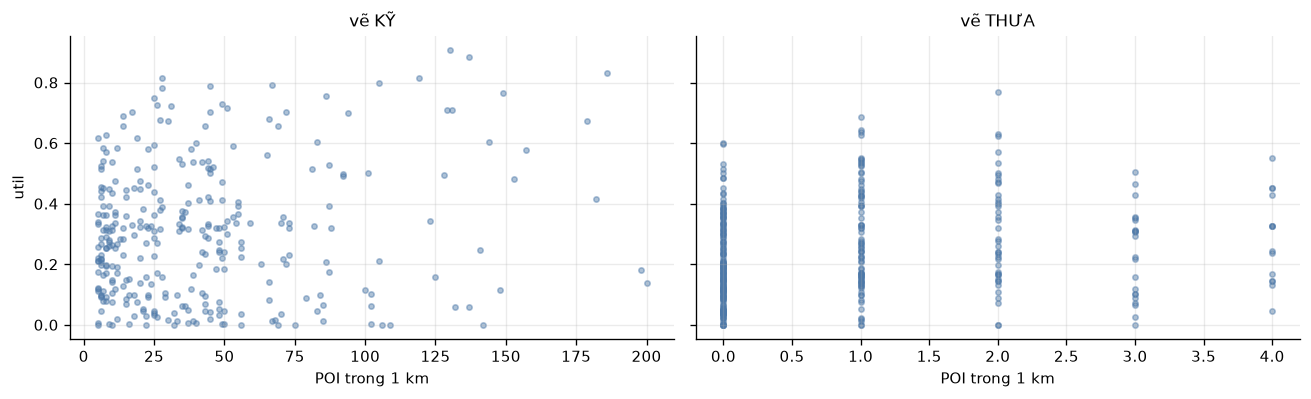

In [9]:
from sklearn.linear_model import RidgeCV  # noqa: E402
from sklearn.model_selection import GroupKFold, cross_val_score  # noqa: E402

F = pq.read_table(ROOT / "data/qa/critique/a20_dac_trung_tram.parquet").to_pandas()
F = F[F.util_reportable.fillna(False) & (F.grade == "GOOD") & F.util.notna()].reset_index(drop=True)
L8 = [
    "fuel",
    "parking_off",
    "parking_street",
    "mall",
    "dept_store",
    "supermarket",
    "market",
    "apartment",
]
F["poi1km"] = F[[f"eu1000_{c}" for c in L8]].sum(axis=1)
nguong = F.poi1km.median()
F["nhom_ban_do"] = np.where(F.poi1km > nguong, "vẽ KỸ", "vẽ THƯA")


def r2(sub, cols):
    X = np.log1p(sub[cols].to_numpy(float))
    g = sub.commune_name.fillna("?").to_numpy()
    k = min(5, max(2, sub.commune_name.nunique()))
    return float(
        np.mean(
            cross_val_score(
                RidgeCV(alphas=np.logspace(-2, 3, 20)),
                X,
                sub.util,
                cv=GroupKFold(k),
                groups=g,
                scoring="r2",
            )
        )
    )


B = ["n_ports", "power_kw_site", "eu1000_dan"]
print(f"ngưỡng chia: {nguong:.0f} POI trong 1 km\n")
for nhom, sub in F.groupby("nhom_ban_do"):
    a, b = r2(sub, B), r2(sub, B + ["poi1km"])
    rho = spearmanr(sub.poi1km, sub.util)
    print(
        f"{nhom:8} n={len(sub):3}  R²(nền)={a:+.4f}  R²(+POI)={b:+.4f}  Δ={b - a:+.4f}   "
        f"Spearman(POI,util)={rho.statistic:+.3f} p={rho.pvalue:.3g}"
    )

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for a, (nhom, sub) in zip(ax, F.groupby("nhom_ban_do")):
    a.scatter(sub.poi1km, sub.util, s=10, alpha=0.45, color="#4C78A8")
    a.set_xlabel("POI trong 1 km")
    a.set_title(nhom, fontsize=10)
ax[0].set_ylabel("util")
plt.tight_layout()
plt.show()

---
# 8 — Kết luận: tệ tới mức nào, tệ kiểu gì, và còn dùng được vào việc gì

## 8.1 — Khối lượng khuyết

| | |
|---|---|
| POI trên 1.000 dân | **2,34** |
| ô không có POI nào **trong ô** | **86,7%** |
| ô không có POI nào **trong 1 km** | **72,4%** |
| **dân sống ở những ô đó** | **3.124.090 người = 35,4% dân Hà Nội** |
| ô **> 5.000 người/km²** mà 0 POI trong 1 km | 105 ô — **585.636 người** |

Dòng cuối không phải "vùng thưa dân". Đó là những nơi mật độ **trên 5.000 người/km²** mà
OpenStreetMap không ghi nhận **một điểm quan tâm nào** trong bán kính một cây số. Không có
cách giải thích nào khác ngoài **khuyết dữ liệu**.

## 8.2 — Khuyết đã CHỨNG MINH được, không phải suy đoán

Không cần nguồn ngoài. Có những thứ chắc chắn tồn tại ở mọi xã/phường:

| Thứ chắc chắn có | Số xã/phường báo **0** | Dân ở vùng đó |
|---|---|---|
| trường học | **0** / 126 | — |
| cây xăng | 27 / 126 *(21,4%)* | 1.571.204 |
| cửa hàng bán lẻ | 32 / 126 *(25,4%)* | 1.715.247 |
| cơ sở y tế | 34 / 126 *(27,0%)* | 1.850.148 |
| chỗ ăn uống | 35 / 126 *(27,8%)* | 2.055.979 |
| **chợ** | **60 / 126 *(47,6%)*** | **3.503.242** |

**Gần một nửa số xã/phường Hà Nội không có một cái chợ nào trong OSM.** Ở Việt Nam điều đó
không thể đúng. Đây là bằng chứng trực tiếp về mức khuyết, và nó ảnh hưởng tới hơn 3,5
triệu người.

Ngược lại, **trường học khuyết 0%** — nghĩa là OSM Hà Nội không "tệ đều". Nó tệ **có chọn lọc**.

## 8.3 — Thiên lệch có hệ thống, và lớn hơn mọi lời giải thích tự nhiên

| Mẫu số chuẩn hoá | Phường ÷ Xã |
|---|---|
| trên 1.000 dân | 6,11× |
| trên km² | 41,76× |
| **trên km² ĐÃ XÂY** *(ảnh vệ tinh ESA — độc lập với OSM)* | **14,12×** |
| trên 100 km đường | 18,18× |

Dòng thứ ba là dòng quan trọng. Diện tích đã xây đo bằng **ảnh vệ tinh**, không liên quan gì
tới OSM. Vậy mà **một km² đất đã xây ở Phường có số POI được ghi nhận gấp 14 lần** một km²
đất đã xây ở Xã.

**Có một cách giải thích tự nhiên phải thừa nhận:** đất xây ở nội thành là cửa hàng, còn đất
xây ở ngoại thành là nhà ở và công trình nông nghiệp. Chênh lệch thật sự tồn tại. Nên con số
14× **không phải toàn bộ là công sức vẽ**. Bằng chứng cho phần công sức vẽ nằm ở mục sau.

## 8.4 — Bằng chứng quyết định: thiên lệch KHÁC NHAU GIỮA CÁC LỚP

Đây là phát hiện quan trọng nhất của cả notebook.

| Lớp | Phường ÷ Xã | |
|---|---|---|
| cây xăng | **1,14×** | gần như không lệch |
| trường học | 1,24× | |
| giải trí · chợ · y tế | 2,7 – 3,1× | |
| bãi đỗ · tiện lợi · văn phòng · siêu thị | 4,3 – 6,4× | |
| khách sạn · chung cư · bán lẻ | 10,4 – 12,5× | |
| ngân hàng | 16,6× | |
| **ăn uống** | **18,24×** | lệch nhất |

**Trải 16 lần giữa lớp lệch ít nhất và lệch nhiều nhất.** Không có lý do thực địa nào giải
thích được điều đó: cây xăng và quán ăn đều phục vụ con người ở cả nội và ngoại thành. Lý do
nằm ở **cách chúng được vẽ**:

> Cây xăng **to, nhìn thấy trên ảnh vệ tinh, và ít** — vẽ hết được. Quán ăn **nhỏ, nhiều, chỉ
> thấy khi có người đi bộ qua với điện thoại** — nên chỉ được vẽ ở nơi có người vẽ.

### Hệ quả: **tỉ trọng thành phần KHÔNG chữa được thiên lệch này**

Ở `l5 §3` tôi chuyển từ *số đếm* sang *tỉ trọng* để khử thiên lệch mật độ, và điều đó đúng
một nửa. Nó khử được thiên lệch **tổng thể**. Nhưng khi mỗi lớp lệch một mức khác nhau, thì
chính **cơ cấu** cũng méo: ở Xã, tỉ trọng quán ăn bị nén xuống không phải vì ít quán ăn, mà
vì quán ăn ở Xã không được vẽ.

**Điều này giải thích ở tầng sâu hơn vì sao `l5 §8` thất bại.** Phân cụm theo cơ cấu POI ra
đúng `commune_kind` (Cramér's V 0,718) không phải vì đô thị và ven đô có cơ cấu chức năng
khác nhau — mà (một phần) vì **chúng có cơ cấu ĐƯỢC VẼ khác nhau**. Không phép biến đổi nào,
kể cả CLR, chữa được điều đó.

**Và nó giải thích một kết quả tôi từng thấy khó hiểu:** ở `l5 §9.4`, **cây xăng** là chỉ báo
dương mạnh nhất cho `util`. Bây giờ thì rõ — cây xăng là lớp **ít méo nhất** (1,14×). Tín
hiệu của nó là tín hiệu thật; tín hiệu của các lớp khác pha lẫn công sức vẽ.

## 8.5 — Nhưng quan hệ POI → nhu cầu KHÔNG phải hiện vật

Phép kiểm quyết định: chia trạm làm hai nửa theo độ dày bản đồ quanh nó.

| Nhóm | n | ΔR² khi thêm POI | Spearman(POI, util) | p |
|---|---|---|---|---|
| vẽ **KỸ** *(> 4 POI/1 km)* | 311 | +0,0504 | +0,081 | **0,152** — không có ý nghĩa |
| vẽ **THƯA** *(≤ 4 POI/1 km)* | 321 | +0,0264 | **+0,237** | **1,75 × 10⁻⁵** |

Kết quả **ngược trực giác**: quan hệ POI ↔ mức sử dụng **mạnh hơn và có ý nghĩa thống kê ở
nửa được vẽ THƯA**, còn ở nửa vẽ kỹ thì không đạt ý nghĩa.

Nếu quan hệ này là hiện vật của công sức vẽ, nó phải mạnh nhất ở nơi vẽ kỹ. Nó làm ngược lại.

**Diễn giải:** POI đang hoạt động như một **chỉ báo CÓ/KHÔNG về tính đô thị**, chứ không phải
một **thước đo mật độ nhu cầu**. Ở vùng vẽ thưa, "có POI nào không" phân biệt được nơi có
hoạt động kinh tế với nơi không. Ở vùng vẽ kỹ, chỗ nào cũng có POI nên đếm thêm không phân
biệt được gì.

## 8.6 — Một cảnh báo về chính phép đo của tôi

Mục 5 đếm được **10.057 cặp POI cùng lớp cách nhau dưới 25 m**. Tôi đặt tên biến là "nghi
trùng lặp", và đó là cách gọi **quá mạnh**: trên một phố ẩm thực, hai quán ăn cách nhau 20 m
là chuyện bình thường, không phải bản ghi trùng. Con số này đo **độ tụ** nhiều hơn đo **trùng
lặp**, và tôi không tách được hai thứ đó bằng dữ liệu đang có. Ghi lại thay vì để nó thành
một "phát hiện" mà nó không phải.

---

# 9 — Dùng POI thế nào cho đúng

| ✅ Được | ❌ Không được |
|---|---|
| Chỉ báo **có/không** về tính đô thị | **Thước đo mật độ** hoạt động kinh tế |
| **Tổng số POI trong 1 km** như một biến liên tục thô | **Cơ cấu / tỉ trọng** giữa các lớp |
| Ưu tiên lớp **ít méo**: cây xăng (1,14×), trường học (1,24×) | Lớp méo nặng: ăn uống (18×), ngân hàng (17×) |
| Vẽ bản đồ POI **kèm bản đồ độ phủ** | Vẽ mật độ POI một mình — nó vẽ **công sức lập bản đồ** |
| Công bố kèm: *"35,4% dân nằm ngoài mọi POI trong 1 km"* | Coi ô 0 POI là "không có hoạt động" |

**Với engine phê duyệt (L6):** POI **không đủ tư cách** tham gia bất kỳ rule loại trừ nào.
Một đơn ở vùng vẽ thưa sẽ luôn trông "vắng POI" — và 35,4% dân Hà Nội sống ở vùng đó. Dùng
POI để từ chối đơn là từ chối theo **mức độ được vẽ bản đồ**, không theo thực địa.

Chỗ POI dùng được là **xếp thứ tự hàng đợi**, cùng với cảnh báo đi kèm khi vị trí nằm trong
vùng vẽ thưa: *"khu vực này có độ phủ POI thấp — điểm số POI không đáng tin ở đây."*